### Librerias

In [23]:
#Importar librerias
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy import stats
from sklearn import metrics
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

### Lectura de Datos

In [24]:
#Leer dataset
df = pd.read_csv('./TelcoClientesFuga.csv')
df = df.drop(columns=["MonthlyCharges","TotalCharges"])

In [25]:
#Eliminar campos en blanco en TotalCharges, y convierte la columna a numeros
# df = df[df['TotalCharges'].str.strip() != '']
# df = df.reset_index(drop=True)
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### Limpieza y Transformacion

In [26]:
#Cambiar No phone/internet service por no
#Al hacer dummies con estas 3 variables al final siempre se termina quitando no phone/internet service
#ya que todas son iguales y al quedar solo con las dummies de yes y no, se puede ver que ambos son el
#opuesto de la otra, lo cual las hace redundantes, por ello tiene mas sentido esto
cols = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

for c in cols:
    df[c] = df[c].replace('No internet service', 'No')

for c in cols:
    df[c] = df[c].map({'Yes': 1, 'No': 0})

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0})

In [27]:
#Se cambia Yes y No por 1 y 0 (Y Tambien Male y Female)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [28]:
#Ya que internet service no es yes, no y otra cosa, sino que es yes(DSL o Fiber optic) o no
#entonces tiene mas sentido hacer dummies
dummies = pd.get_dummies(df['InternetService'], prefix='InternetService').astype(int)
dummies = dummies.drop('InternetService_Fiber optic', axis=1)
df = pd.concat([df, dummies], axis=1)
df = df.drop('InternetService', axis=1)

In [29]:
#Estas tambien se pueden convertir a dummies aunque no se que tan importante seran
#Se puede comentar por si no se consideran
dummies = pd.get_dummies(df['Contract'], prefix='Contract').astype(int)
dummies = dummies.drop('Contract_Month-to-month', axis=1)
df = pd.concat([df, dummies], axis=1)
df = df.drop('Contract', axis=1)

dummies = pd.get_dummies(df['PaymentMethod'], prefix='PaymentMethod').astype(int)
dummies = dummies.drop('PaymentMethod_Mailed check', axis=1)
df = pd.concat([df, dummies], axis=1)
df = df.drop('PaymentMethod', axis=1)

In [30]:
#Se cambia el nombre de algunas columnas para que todos tenga el mismo estilo de capitalizacion
df = df.rename(columns={'gender': 'Gender'})
df = df.rename(columns={'tenure': 'Tenure'})
df = df.rename(columns={'customerID': 'CustomerID'})

In [31]:
#Descargar el nuevo y limpio csv
#df.to_csv('TelcoClientesLimpio.csv', index=False)

### Metricas para mas Limpieza

In [32]:
#Se ve las correlaciones
df = df.select_dtypes(include=[np.number])
df.columns = df.columns.str.strip()
matriz_correlacion = df.corr()
caracteristicas_alta_correlacion = [(col1, col2, matriz_correlacion.loc[col1,col2])
                                   for col1 in matriz_correlacion.columns
                                   for col2 in matriz_correlacion.columns
                                   if col1 != col2 and abs(matriz_correlacion.loc[col1,col2])>0.8]
multicolinealidad_df = pd.DataFrame(caracteristicas_alta_correlacion, columns = ["Caracteristica 1","Caracteristica 2","Correlacion"])
print("?\nCaracteristicas altamente correlacionadas:\n", multicolinealidad_df)

?
Caracteristicas altamente correlacionadas:
 Empty DataFrame
Columns: [Caracteristica 1, Caracteristica 2, Correlacion]
Index: []


In [33]:
#Se ve el vif
vif_df = pd.DataFrame()
vif_df["Caracteristica"]  = df.columns 
vif_df["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
print("\nFactor de Inflacion de Varianza (VIF) para cada caracteristica:\n",vif_df)


Factor de Inflacion de Varianza (VIF) para cada caracteristica:
                              Caracteristica       VIF
0                                    Gender  1.952709
1                             SeniorCitizen  1.362689
2                                   Partner  2.823418
3                                Dependents  1.967641
4                                    Tenure  7.815730
5                              PhoneService  7.456312
6                             MultipleLines  2.456109
7                            OnlineSecurity  1.980859
8                              OnlineBackup  2.095223
9                          DeviceProtection  2.241846
10                              TechSupport  2.092398
11                              StreamingTV  2.628839
12                          StreamingMovies  2.653376
13                         PaperlessBilling  2.805153
14                                    Churn  1.754796
15                      InternetService_DSL  1.890774
16              

### Preparacion para el Modelo

In [34]:
columnas_caracteristicas = ['Gender','SeniorCitizen','Partner','Dependents','Tenure','PhoneService','MultipleLines',
                            'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                            'PaperlessBilling','InternetService_DSL','InternetService_No','Contract_One year',
                            'Contract_Two year','PaymentMethod_Bank transfer (automatic)','PaymentMethod_Credit card (automatic)',
                            'PaymentMethod_Electronic check']
X = df[columnas_caracteristicas]
y = df.Churn

In [35]:
X2 = sm.add_constant(X).rename(columns={'const':'intercept'})
X2 = X2.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

X2 = X2.dropna()
y = y.dropna()
est = sm.OLS(y, X2)
est2 = est.fit()
est2.conf_int(alpha=0.05, cols=None)
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Churn   R-squared:                       0.279
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     129.5
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:27:00   Log-Likelihood:                -3082.1
No. Observations:                7040   AIC:                             6208.
Df Residuals:                    7018   BIC:                             6359.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [36]:
p_values = est2.pvalues
print(p_values)

intercept                                  1.605536e-114
Gender                                      6.251852e-01
SeniorCitizen                               6.196440e-04
Partner                                     8.596692e-01
Dependents                                  9.927070e-02
Tenure                                      2.418851e-51
PhoneService                                8.401507e-04
MultipleLines                               2.087652e-04
OnlineSecurity                              1.720711e-08
OnlineBackup                                5.428366e-04
DeviceProtection                            9.991892e-02
TechSupport                                 2.179292e-08
StreamingTV                                 8.946775e-03
StreamingMovies                             5.437025e-03
PaperlessBilling                            6.109365e-06
InternetService_DSL                         2.925739e-27
InternetService_No                          9.301962e-48
Contract_One year              

In [37]:
caracteristicas = est2.pvalues[est2.pvalues<0.05].index
print(caracteristicas.values)
X_seleccionadas = X2[caracteristicas]

['intercept' 'SeniorCitizen' 'Tenure' 'PhoneService' 'MultipleLines'
 'OnlineSecurity' 'OnlineBackup' 'TechSupport' 'StreamingTV'
 'StreamingMovies' 'PaperlessBilling' 'InternetService_DSL'
 'InternetService_No' 'Contract_One year' 'Contract_Two year'
 'PaymentMethod_Electronic check']


### Division de los Datos

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seleccionadas, y, test_size=0.20, random_state=16
)

smote = SMOTE(random_state=16)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

### Modelado de Datos

In [39]:
modelo = LogisticRegression(random_state=16, max_iter=1000)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [40]:
matriz_confusion = metrics.confusion_matrix(y_test, y_pred)
matriz_confusion

array([[937, 122],
       [157, 192]], dtype=int64)

### Visualizacion y Metricas

Text(0.5, 427.9555555555555, 'Prediccion')

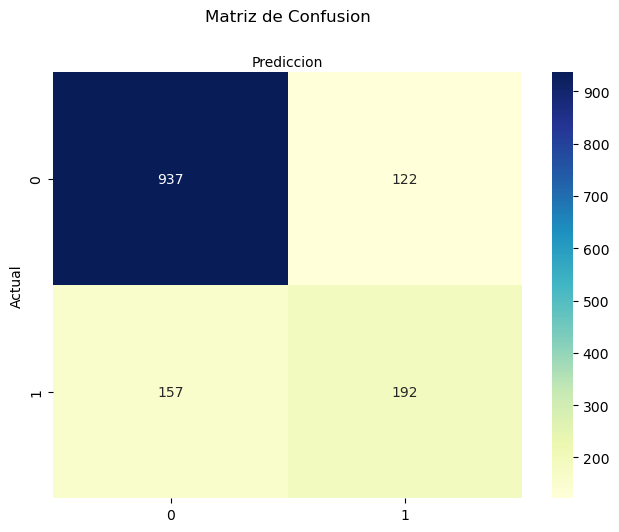

In [41]:
nombres_clases=[0,1]
fig, ax = plt.subplots()
marcas_verificacion = np.arange(len(nombres_clases))
plt.xticks(marcas_verificacion, nombres_clases)
plt.yticks(marcas_verificacion, nombres_clases)

sns.heatmap(pd.DataFrame(matriz_confusion), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Matriz de Confusion',y=1.1)
plt.ylabel('Actual')
plt.xlabel('Prediccion')

In [42]:
nombres_target = ['No Fuga','Fuga']
print(classification_report(y_test, y_pred, target_names=nombres_target))

              precision    recall  f1-score   support

     No Fuga       0.86      0.88      0.87      1059
        Fuga       0.61      0.55      0.58       349

    accuracy                           0.80      1408
   macro avg       0.73      0.72      0.72      1408
weighted avg       0.80      0.80      0.80      1408



In [43]:
y_pred = y_pred.astype(int)
#(True Positive + True Negative) / Total Predictions
Accuracy =metrics.accuracy_score(y_test, y_pred)
#True Positive / (True Positive + False Positive)
Precision = metrics.precision_score(y_test, y_pred)
#True Positive / (True Positive + False Negative)
Sensitivity_recall = metrics.recall_score(y_test, y_pred)
#True Negative / (True Negative + False Positive)
Specificity = metrics.recall_score(y_test, y_pred, pos_label=0)
#2 * ((Precision * Sensitivity) / (Precision + Sensitivity))
F1_score = metrics.f1_score(y_test, y_pred)
print({"Exactitud":Accuracy,"Precision":Precision,
      "Sensibilidad_recall":Sensitivity_recall,
      "Especificidad":Specificity,"F1_score":F1_score})

{'Exactitud': 0.8018465909090909, 'Precision': 0.6114649681528662, 'Sensibilidad_recall': 0.5501432664756447, 'Especificidad': 0.8847969782813976, 'F1_score': 0.579185520361991}


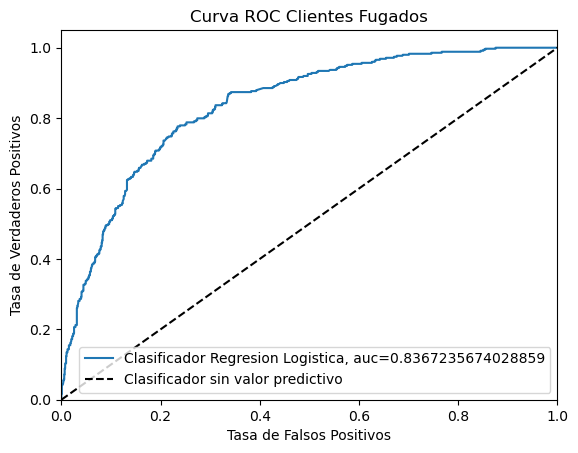

In [44]:
ns_probs = [0 for _ in range(len(y_test))]
y_test = y_test.astype(int)

y_pred_proba = modelo.predict_proba(X_test)[::,1]
ns_fpr, ns_tpr, thresholds = roc_curve(y_test, ns_probs)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="Clasificador Regresion Logistica, auc="+str(auc))
plt.plot([0,1],[0,1], 'k--', label='Clasificador sin valor predictivo')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Clientes Fugados')
plt.legend(loc=4)
plt.show()